# Part 4: AI Solution Design for a Business Problem

**Domain:** Insurance
**Business Problem:** Automated Fraud Detection in Insurance Claims
**Reference Files:** `ai_usecase_reference_catalog.csv`, `business_kpi_sample.csv`

## Task 1: Choose a Business Domain

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# load reference catalog
catalog = pd.read_csv('ai_usecase_reference_catalog.csv')
print('Domains available:')
print(catalog['domain'].value_counts().to_string())
catalog.head()

Domains available:
domain
Insurance           1
Healthcare          1
Retail              1
Telecom             1
Finance             1
Manufacturing       1
Agriculture         1
Education           1
Transportation      1
Customer Support    1


,domain,business_problem,data_required,ai_task_type,candidate_model,evaluation_metrics,responsible_ai_risk
0,Insurance,Claim fraud detection,Structured claim records + claim documents,Anomaly detection / Classification,Feed-forward neural network or gradient boosting,"Precision, recall, fraud catch rate","False fraud flag, unfair treatment of genuine ..."
1,Healthcare,Medical image triage,X-ray or scan images,Image classification,CNN or transfer learning model,"Recall, sensitivity, review time reduction","Incorrect diagnosis, privacy risk, need human ..."
2,Retail,Product image search,Product catalog images,Image classification / Similarity search,CNN embeddings / transfer learning,"Top-k accuracy, conversion rate","Wrong recommendations, biased catalog visibility"
3,Telecom,Customer churn prediction,"Usage, billing, support tickets",Classification,Feed-forward neural network,"AUC, recall, retention uplift","Targeting customers unfairly, privacy concerns"
4,Finance,Suspicious transaction detection,Transaction history,Anomaly detection / Classification,Neural network or autoencoder,"Precision, recall, investigation efficiency",False positives blocking legitimate users


In [2]:
# selected domain: Insurance
selected = catalog[catalog['domain']=='Insurance']
selected.T

,0
domain,Insurance
business_problem,Claim fraud detection
data_required,Structured claim records + claim documents
ai_task_type,Anomaly detection / Classification
candidate_model,Feed-forward neural network or gradient boosting
evaluation_metrics,"Precision, recall, fraud catch rate"
responsible_ai_risk,"False fraud flag, unfair treatment of genuine ..."


**Selected Domain:** Insurance

**Business Problem:** Insurance companies process thousands of claims daily. A significant portion are fraudulent — exaggerated damages, staged accidents, identity theft. Manual review is slow, expensive, and inconsistent.

**Business Goal:** Build an AI system that automatically scores each claim for fraud risk so investigators can focus on high-risk cases.

**Users/Stakeholders:** Claims handlers, fraud investigation team, compliance officers, customers.

**Current Manual Process:** Each claim is reviewed by a human analyst who checks documents, history, and red flags. This takes 2–3 hours per claim and has a high miss rate for sophisticated fraud.

## Task 2: Define the Business Problem

- **What problem is being solved?** Detecting fraudulent insurance claims before payout
- **Who are the users/stakeholders?** Claims team, fraud investigators, compliance, customers
- **Current manual/traditional process:** Human analysts review each claim individually
- **Limitations:** Slow, inconsistent, misses patterns across large volumes of data
- **AI Opportunity:** A model can screen thousands of claims instantly, flagging anomalies based on patterns learned from historical fraud cases

## Task 3: Identify the AI Task Type

**AI Task Type:** Binary Classification (Fraud / Not Fraud)

| Aspect | Detail |
|---|---|
| Input | Structured claim records: amount, type, claimant history, timing, location |
| Output | Fraud probability score (0-1) + binary flag |
| Learning Type | Supervised learning (labeled historical fraud data required) |

**Why Classification?** We have labeled historical data (confirmed fraud cases). The model learns patterns that distinguish fraud from legitimate claims. Output is a yes/no decision with a confidence score for prioritization.

## Task 4: Data Requirement Plan

| Data Type | Description | Source | Format |
|---|---|---|---|
| Claim records | Amount, date, type, location, product | Internal CRM/Policy DB | Structured CSV/SQL |
| Claimant history | Prior claims, payout history, account age | Internal | Structured |
| Agent notes | Free text descriptions of the claim | Internal ticketing system | Unstructured text |
| Fraud labels | Confirmed fraud/legitimate outcomes | Fraud investigation team | Binary label (0/1) |
| External data | Vehicle info, hospital records, geo risk | Third-party APIs | JSON/Structured |

**Data Challenges:**
- **Class imbalance** — fraud is ~2-5% of claims → need SMOTE or class weighting
- **Missing values** — older records may be incomplete → median/mode imputation
- **Data freshness** — fraud patterns evolve → periodic retraining required
- **Privacy** — PII must be anonymized → GDPR/local regulations compliance
- **Input features:** ~20-30 structured features; optionally text features from notes

## Task 5: Model Recommendation

| Model | Pros | Cons | Verdict |
|---|---|---|---|
| Logistic Regression | Simple, interpretable | Misses non-linear patterns | Baseline only |
| Random Forest | Non-linear, feature importance | Slower prediction | Good secondary |
| **XGBoost (Primary)** | High accuracy, handles imbalance, fast | Needs tuning | **Recommended** |
| Feed-Forward NN | Complex patterns | Needs large data, less interpretable | Optional for large datasets |

**Recommended:** XGBoost as primary model. Strong on tabular data, native handling of missing values, supports class weights.

**NN Architecture (alternative):**
- Input: ~25 features
- Dense(128, ReLU) → Dense(64, ReLU) → Dense(1, Sigmoid)
- Loss: binary_crossentropy with class_weight
- Threshold: tunable (default 0.5) — lower threshold catches more fraud at cost of more false positives

## Task 6: Evaluation Plan

In [3]:
# load and visualize KPI data
kpi = pd.read_csv('business_kpi_sample.csv')
print('KPI shape:', kpi.shape)
kpi.head()

KPI shape: (12, 6)


,month,manual_processing_hours,average_resolution_time_hours,error_rate_percent,customer_satisfaction_score,monthly_cases
0,2025-01,509,35.2,7.32,6.4,2542
1,2025-01,567,34.9,6.23,6.8,2570
2,2025-03,468,44.7,7.65,6.8,2576
3,2025-04,503,34.6,8.94,6.9,2746
4,2025-05,536,32.5,11.16,6.6,2789


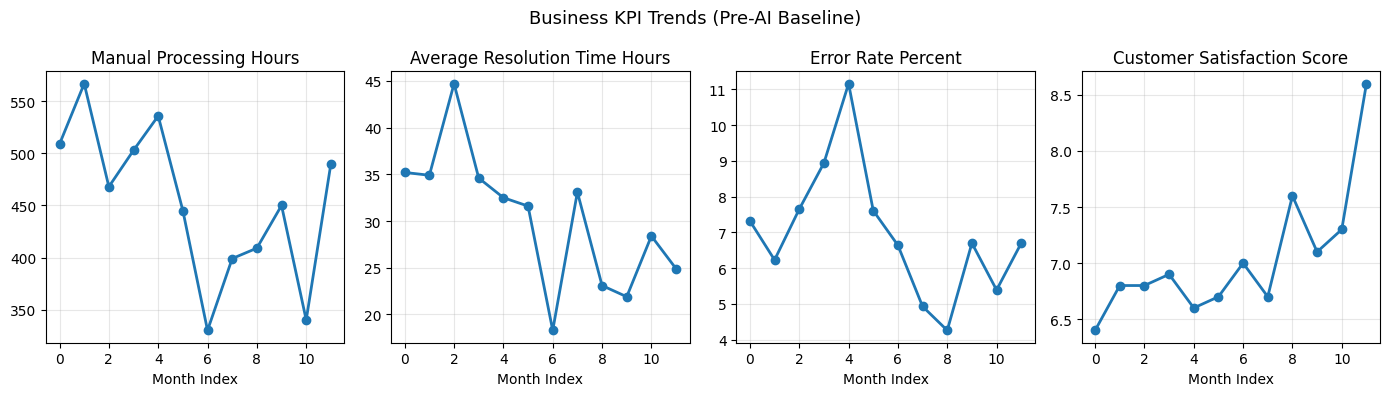

In [4]:
os.makedirs('results', exist_ok=True)
os.makedirs('diagrams', exist_ok=True)

# plot available KPI trends
numeric_cols = kpi.select_dtypes(include='number').columns.tolist()
n = min(len(numeric_cols), 4)
fig, axes = plt.subplots(1, n, figsize=(14, 4))
if n == 1: axes = [axes]
for i, col in enumerate(numeric_cols[:n]):
    axes[i].plot(kpi.index, kpi[col], marker='o', linewidth=2)
    axes[i].set_title(col.replace('_',' ').title())
    axes[i].set_xlabel('Month Index')
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Business KPI Trends (Pre-AI Baseline)', fontsize=13)
plt.tight_layout()
plt.savefig('results/kpi_trends.png', dpi=150)
plt.show()

### Technical Metrics

| Metric | Why It Matters |
|---|---|
| **Recall (Fraud class)** | Most important — must catch as many fraud cases as possible |
| **Precision (Fraud class)** | Too many false flags wastes investigator time |
| **F1-Score** | Balances precision and recall for the imbalanced class |
| **AUC-ROC** | Overall discrimination ability of the model |
| **Confusion Matrix** | Shows TP, TN, FP, FN breakdown |

### Business Metrics

| KPI | Expected Impact with AI |
|---|---|
| Fraud catch rate | Increase from ~40% to 70%+ |
| Manual review hours | Reduce by ~40% (AI pre-filters low-risk claims) |
| Avg resolution time | Faster for legitimate claimants |
| Error rate | More consistent than fatigued human reviewers |
| Customer satisfaction | Higher — legitimate claims resolved faster |

### Failure Cases / Human Review
- All flagged claims (score > 0.7) go to human investigator
- Model is reviewed quarterly for performance drift
- SHAP values generated per claim for explainability

## Task 7: Responsible AI Considerations

| Risk | Description | Mitigation |
|---|---|---|
| **False fraud flags** | Legitimate claims wrongly denied — financial and reputational harm | Human-in-the-loop review for all flagged claims |
| **Bias in model** | Historical data may reflect biased past decisions | Fairness audits using demographic parity / equalized odds |
| **Data privacy** | Claimant PII is sensitive (GDPR / local laws) | Anonymization, role-based access, audit logs |
| **Model drift** | Fraud patterns change over time | Monthly monitoring + quarterly retraining |
| **Lack of explainability** | Complex models hard to explain to regulators | SHAP values for per-claim explanations |
| **Over-reliance on AI** | Investigators stop exercising judgment | AI gives score + top reasons; human makes final decision |

## Task 8: Final One-Page Solution Summary

---

### AI Solution: Insurance Claim Fraud Detection System

**Business Problem:**  
Insurance companies lose revenue to fraudulent claims. Manual review is slow and misses sophisticated fraud patterns.

**Proposed AI Solution:**  
Supervised binary classification using **XGBoost** trained on historical labeled claim data. The model scores each new claim for fraud risk (0–1) in real time.

**Required Data:**  
Structured claim records + claimant history + confirmed fraud labels. Minimum ~50,000 historical records for a reliable model.

**Model Recommendation:**  
XGBoost (primary) with class weighting for imbalanced data. Feed-forward NN as alternative for larger datasets.

**Evaluation:**  
Primary: **Recall on fraud class**. Secondary: Precision, F1-score. Business: fraud catch rate, manual hours saved, resolution time.

**Deployment:**  
Model runs as a REST API. When a claim is submitted, it receives a risk score instantly. High-risk claims (score > 0.7) route to fraud team with SHAP explanations. Low-risk claims are fast-tracked.

**Responsible AI:**  
Human review mandatory for all flagged claims. Quarterly fairness audits. All data handling complies with privacy regulations.

**Expected Business Impact:**
- ~35% reduction in undetected fraud losses
- ~40% reduction in manual review hours  
- Faster legitimate claim resolution → higher customer satisfaction

---